Benson Luo HW8, USC ID:9649157234

source:

Spectral clustering: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

In [1]:
import pandas as pd

In [31]:
col_name = ["ID", "Diagnosis"] + [f"{i}_cell" for i in range(1,31)]
df = pd.read_csv("wdbc.data", names=col_name)
df

,ID,Diagnosis,1_cell,2_cell,3_cell,4_cell,5_cell,6_cell,7_cell,8_cell,...,21_cell,22_cell,23_cell,24_cell,25_cell,26_cell,27_cell,28_cell,29_cell,30_cell
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [33]:
df["Diagnosis"] = df["Diagnosis"].map({"B": 0, "M": 1})
df

,ID,Diagnosis,1_cell,2_cell,3_cell,4_cell,5_cell,6_cell,7_cell,8_cell,...,21_cell,22_cell,23_cell,24_cell,25_cell,26_cell,27_cell,28_cell,29_cell,30_cell
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [38]:
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

b(i)

In [51]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [46]:
M = 30
train_acc_list = []
train_prec_list = []
train_rec_list = []
train_f1_list = []
train_auc_list = []
test_acc_list = []
test_prec_list = []
test_rec_list = []
test_f1_list = []
test_auc_list = []

C_list = []

In [47]:
for m in range(M):

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    rng = np.random.default_rng(3000 + m)

    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    n_pos_test = int(0.20 * len(idx_pos))
    n_neg_test = int(0.20 * len(idx_neg))

    test_idx = np.concatenate([idx_pos[:n_pos_test], idx_neg[:n_neg_test]])
    train_idx = np.concatenate([idx_pos[n_pos_test:], idx_neg[n_neg_test:]])

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    Cs = [0.001, 0.01, 0.1, 1, 10]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3000 + m)

    best_C = None
    best_acc = -1

    for C in Cs:
        cv_acc_list = []
        for train_i, val_i in skf.split(X_train_std, y_train):
            X_tr = X_train_std[train_i]
            y_tr = y_train.iloc[train_i]
            X_val = X_train_std[val_i]
            y_val = y_train.iloc[val_i]

            svm = LinearSVC(C=C, penalty="l1", dual=False, max_iter=5000)
            svm.fit(X_tr, y_tr)

            y_val_pred = svm.predict(X_val)
            cv_acc_list.append(accuracy_score(y_val, y_val_pred))

        mean_acc = np.mean(cv_acc_list)
        if mean_acc > best_acc:
            best_acc = mean_acc
            best_C = C

    C_list.append(best_C)

    svm_final = LinearSVC(C=best_C, penalty="l1", dual=False, max_iter=5000)
    svm_final.fit(X_train_std, y_train)

    y_train_pred = svm_final.predict(X_train_std)
    y_test_pred = svm_final.predict(X_test_std)

    train_acc_list.append(accuracy_score(y_train, y_train_pred))
    train_prec_list.append(precision_score(y_train, y_train_pred))
    train_rec_list.append(recall_score(y_train, y_train_pred))
    train_f1_list.append(f1_score(y_train, y_train_pred))
    train_auc_list.append(roc_auc_score(y_train, svm_final.decision_function(X_train_std)))

    test_acc_list.append(accuracy_score(y_test, y_test_pred))
    test_prec_list.append(precision_score(y_test, y_test_pred))
    test_rec_list.append(recall_score(y_test, y_test_pred))
    test_f1_list.append(f1_score(y_test, y_test_pred))
    test_auc_list.append(roc_auc_score(y_test, svm_final.decision_function(X_test_std)))

    if m == 0:
        X_test_r0 = X_test_std
        y_test_r0 = y_test
        model_r0 = svm_final
        conf_train_r0 = confusion_matrix(y_train, y_train_pred)
        conf_test_r0 = confusion_matrix(y_test, y_test_pred)

summary = pd.DataFrame({
    "set": ["train", "test"],
    "accuracy_mean": [np.mean(train_acc_list), np.mean(test_acc_list)],
    "accuracy_std":  [np.std(train_acc_list), np.std(test_acc_list)],

    "precision_mean": [np.mean(train_prec_list), np.mean(test_prec_list)],
    "precision_std":  [np.std(train_prec_list), np.std(test_prec_list)],

    "recall_mean": [np.mean(train_rec_list), np.mean(test_rec_list)],
    "recall_std":  [np.std(train_rec_list), np.std(test_rec_list)],

    "f1_mean": [np.mean(train_f1_list), np.mean(test_f1_list)],
    "f1_std": [np.std(train_f1_list), np.std(test_f1_list)],

    "auc_mean": [np.mean(train_auc_list), np.mean(test_auc_list)],
    "auc_std": [np.std(train_auc_list), np.std(test_auc_list)],

    "best_C_median": [np.median(C_list), np.median(C_list)]
})

print(summary)

     set  accuracy_mean  accuracy_std  precision_mean  precision_std  \
0  train       0.985892      0.004827        0.990228       0.006243   
1   test       0.968142      0.016254        0.970943       0.023617   

   recall_mean  recall_std   f1_mean    f1_std  auc_mean   auc_std  \
0     0.971765    0.009534  0.980887  0.006571  0.997626  0.001222   
1     0.942857    0.032297  0.956378  0.022626  0.991918  0.007523   

   best_C_median  
0            0.1  
1            0.1  


In [50]:
import matplotlib.pyplot as plt

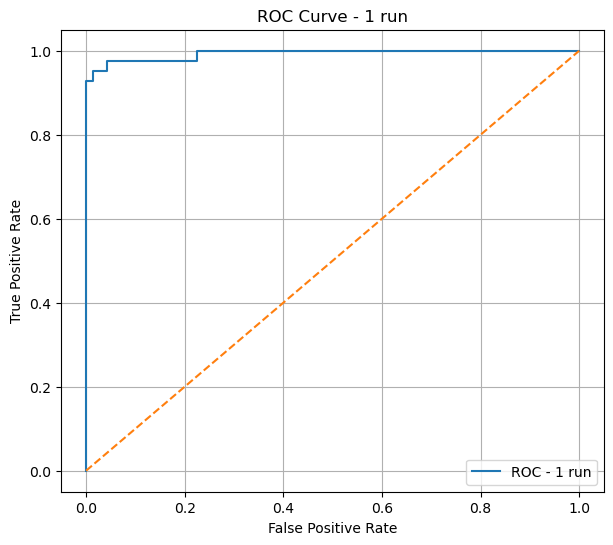


Confusion matrix - 1 run train:
[[285   1]
 [  5 165]]

Confusion matrix - 1 run test:
[[70  1]
 [ 2 40]]


In [54]:

y_score = model_r0.decision_function(X_test_r0)
fpr, tpr, _ = roc_curve(y_test_r0, y_score)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label="ROC - 1 run")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 1 run")
plt.grid()
plt.legend()
plt.show()

print("\nConfusion matrix - 1 run train:")
print(conf_train_r0)

print("\nConfusion matrix - 1 run test:")
print(conf_test_r0)

b(ii)

In [71]:
from sklearn.model_selection import GridSearchCV

In [66]:
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)
rng.shuffle(idx_pos_train)
rng.shuffle(idx_neg_train)
n_pos_labeled = len(pos_idx) // 2
n_neg_labeled = len(neg_idx) // 2
labeled_idx = np.concatenate([pos_idx[:n_pos_labeled], neg_idx[:n_neg_labeled]])
unlabeled_idx = np.concatenate([pos_idx[n_pos_labeled:], neg_idx[n_neg_labeled:]])


In [68]:
X_labeled = X_train_std[labeled_idx]
y_labeled = y_train.iloc[labeled_idx].values
X_unlabeled = X_train_std[unlabeled_idx]
y_unlabeled_true = y_train.iloc[unlabeled_idx].values

{'train_acc': 0.9977000919963201, 'train_precision': 0.9962311557788944, 'train_recall': 0.9974842767295597, 'train_f1': 0.9968573224387178, 'train_auc': 0.9999197303670055, 'test_acc': 0.9380530973451328, 'test_precision': 1.0, 'test_recall': 0.8333333333333334, 'test_f1': 0.9090909090909091, 'test_auc': 0.9889336016096579, 'train_confusion_matrix': array([[1376,    3],
       [   2,  793]], dtype=int64), 'test_confusion_matrix': array([[71,  0],
       [ 7, 35]], dtype=int64)}


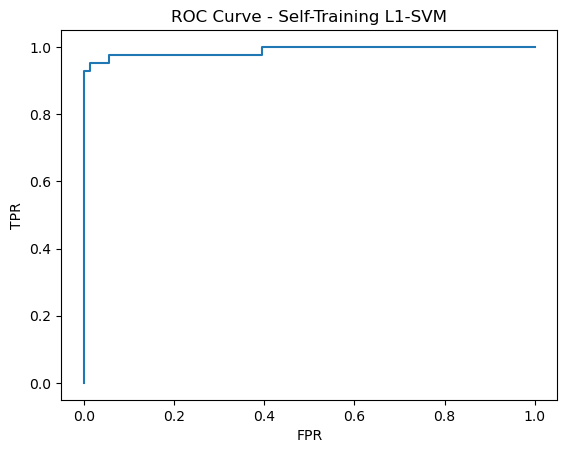

In [89]:
X_unl = X_unlabeled.copy()
remaining_idx = np.arange(len(X_unlabeled))

param_grid = {"C":[0.001, 0.01, 0.1, 1, 10]}
base_svm = LinearSVC(penalty="l1", dual=False)

clf = GridSearchCV(base_svm, param_grid, cv=5)
clf.fit(X_labeled, y_labeled)

svm = clf.best_estimator_
for m in range(M):

    if len(X_unl) == 0:
        break

    dist = svm.decision_function(X_unl)
    farthest = np.argmax(np.abs(dist))

    x_new = X_unl[farthest].reshape(1, -1)
    pseudo_label = svm.predict(x_new)[0]

    X_labeled = np.vstack([X_labeled, x_new])
    y_labeled = np.append(y_labeled, pseudo_label)

    mask = np.ones(len(X_unl), dtype=bool)
    mask[farthest] = False
    X_unl = X_unl[mask]

    svm = LinearSVC(penalty="l1", dual=False, C=best_C)
    svm.fit(X_labeled, y_labeled)


train_pred = svm.predict(X_labeled)
train_decision = svm.decision_function(X_labeled)

test_pred = svm.predict(X_test_std)
test_decision = svm.decision_function(X_test_std)

results = {
    "train_acc": accuracy_score(y_labeled, train_pred),
    "train_precision": precision_score(y_labeled, train_pred),
    "train_recall": recall_score(y_labeled, train_pred),
    "train_f1": f1_score(y_labeled, train_pred),
    "train_auc": roc_auc_score(y_labeled, train_decision),

    "test_acc": accuracy_score(y_test, test_pred),
    "test_precision": precision_score(y_test, test_pred),
    "test_recall": recall_score(y_test, test_pred),
    "test_f1": f1_score(y_test, test_pred),
    "test_auc": roc_auc_score(y_test, test_decision),

    "train_confusion_matrix": confusion_matrix(y_labeled, train_pred),
    "test_confusion_matrix": confusion_matrix(y_test, test_pred)
}

print(results)

fpr, tpr, _ = roc_curve(y_test, test_decision)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Self-Training L1-SVM")
plt.show()

b(iii)

In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

In [114]:
train_acc_list = []
train_prec_list = []
train_rec_list = []
train_f1_list = []
train_auc_list = []

test_acc_list = []
test_prec_list = []
test_rec_list = []
test_f1_list = []
test_auc_list = []

roc_fpr_train0 = None
roc_tpr_train0 = None
roc_fpr_test0 = None
roc_tpr_test0 = None
conf_train0 = None
conf_test0 = None

for run in range(M):

    kmeans = KMeans(n_clusters=2, n_init=20, random_state=None)
    kmeans.fit(X_train_std)

    labels_train_km = kmeans.labels_
    centers = kmeans.cluster_centers_

    pred_labels_train = np.zeros(len(X_train_std))

    for c in [0, 1]:

        cluster_members = np.where(labels_train_km == c)[0]

        if len(cluster_members) > 30:
            dists = pairwise_distances(X_train_std[cluster_members], centers[c].reshape(1, -1))
            closest30 = cluster_members[np.argsort(dists[:, 0])[:30]]
        else:
            closest30 = cluster_members

        true_labels = y_train.iloc[closest30].values

        majority = 1 if np.sum(true_labels) >= (len(true_labels) / 2) else 0
        pred_labels_train[cluster_members] = majority


    y_train_arr = y_train.values
    train_acc_list.append(accuracy_score(y_train_arr, pred_labels_train))
    train_prec_list.append(precision_score(y_train_arr, pred_labels_train))
    train_rec_list.append(recall_score(y_train_arr, pred_labels_train))
    train_f1_list.append(f1_score(y_train_arr, pred_labels_train))

    dist_c0 = np.linalg.norm(X_train_std - centers[0], axis=1)
    dist_c1 = np.linalg.norm(X_train_std - centers[1], axis=1)
    score_train = dist_c1 - dist_c0
    train_auc_list.append(roc_auc_score(y_train_arr, score_train))

    if run == 0:
        fpr, tpr, _ = roc_curve(y_train_arr, score_train)
        roc_fpr_train0 = fpr
        roc_tpr_train0 = tpr
        conf_train0 = confusion_matrix(y_train_arr, pred_labels_train)

    dist_test_c0 = np.linalg.norm(X_test_std - centers[0], axis=1)
    dist_test_c1 = np.linalg.norm(X_test_std - centers[1], axis=1)
    pred_labels_test = (dist_test_c1 < dist_test_c0).astype(int)

    y_test_arr = y_test.values
    test_acc_list.append(accuracy_score(y_test_arr, pred_labels_test))
    test_prec_list.append(precision_score(y_test_arr, pred_labels_test))
    test_rec_list.append(recall_score(y_test_arr, pred_labels_test))
    test_f1_list.append(f1_score(y_test_arr, pred_labels_test))

    score_test = dist_test_c1 - dist_test_c0
    test_auc_list.append(roc_auc_score(y_test_arr, score_test))

    if run == 0:
        fpr_t, tpr_t, _ = roc_curve(y_test_arr, score_test)
        roc_fpr_test0 = fpr_t
        roc_tpr_test0 = tpr_t
        conf_test0 = confusion_matrix(y_test_arr, pred_labels_test)


print("Result summary")
print("Train: ACC=%.4f, P=%.4f, R=%.4f, F1=%.4f, AUC=%.4f" %
      (np.mean(train_acc_list), np.mean(train_prec_list), np.mean(train_rec_list),
       np.mean(train_f1_list), np.mean(train_auc_list)))

print("Test : ACC=%.4f, P=%.4f, R=%.4f, F1=%.4f, AUC=%.4f" %
      (np.mean(test_acc_list), np.mean(test_prec_list), np.mean(test_rec_list),
       np.mean(test_f1_list), np.mean(test_auc_list)))

Result summary
Train: ACC=0.9079, P=0.9000, R=0.8471, F1=0.8727, AUC=0.5317
Test : ACC=0.4726, P=0.4962, R=0.4794, F1=0.4785, AUC=0.5313


In [121]:
n_init_kmeans = 20              
closest_k = 30                

y_train_arr = np.asarray(y_train)
y_test_arr = np.asarray(y_test)

train_acc_list = []
train_prec_list = []
train_rec_list = []
train_f1_list = []
train_auc_list = []

test_acc_list = []
test_prec_list = []
test_rec_list = []
test_f1_list = []
test_auc_list = []

roc_fpr_run0 = None
roc_tpr_run0 = None
conf_train_run0 = None
conf_test_run0 = None

for run in range(M):
    random_state = 1000 + run

    kmeans = KMeans(n_clusters=2, n_init=n_init_kmeans, random_state=random_state)
    kmeans.fit(X_train_std)
    centers = kmeans.cluster_centers_        

    cluster_label_map = {}   
    for k in range(2):
        dists = np.linalg.norm(X_train_std - centers[k], axis=1)
        idx_sorted = np.argsort(dists)
        topk = idx_sorted[:min(closest_k, len(idx_sorted))]
        topk_labels = y_train_arr[topk]
        counts = np.bincount(topk_labels)
        if len(counts) == 0:
            maj_label = 0
        else:
            maj_label = np.argmax(counts)  # returns label with highest count
        cluster_label_map[k] = int(maj_label)


    dists_to_centers = np.linalg.norm(
        X_train_std[:, None, :] - centers[None, :, :], axis=2
    )  
    nearest_cluster_train = np.argmin(dists_to_centers, axis=1)  
    train_pred_labels = np.array([cluster_label_map[c] for c in nearest_cluster_train])


    pos_centers = [k for k,lab in cluster_label_map.items() if lab == 1]
    if len(pos_centers) >= 1:
        pos_idx = pos_centers[0]
        other_idx = 1 - pos_idx
        score_train = dists_to_centers[:, other_idx] - dists_to_centers[:, pos_idx]
    else:
        score_train = -dists_to_centers[:,0]

    train_acc_list.append(accuracy_score(y_train_arr, train_pred_labels))
    train_prec_list.append(precision_score(y_train_arr, train_pred_labels, zero_division=0))
    train_rec_list.append(recall_score(y_train_arr, train_pred_labels, zero_division=0))
    train_f1_list.append(f1_score(y_train_arr, train_pred_labels, zero_division=0))
    try:
        train_auc_list.append(roc_auc_score(y_train_arr, score_train))
    except:
        train_auc_list.append(np.nan)

    dists_test = np.linalg.norm(X_test_std[:, None, :] - centers[None, :, :], axis=2)  # (n_test,2)
    nearest_cluster_test = np.argmin(dists_test, axis=1)
    test_pred_labels = np.array([cluster_label_map[c] for c in nearest_cluster_test])

    if len(pos_centers) >= 1:
        pos_idx = pos_centers[0]
        other_idx = 1 - pos_idx
        score_test = dists_test[:, other_idx] - dists_test[:, pos_idx]
    else:
        score_test = -dists_test[:,0]

    test_acc_list.append(accuracy_score(y_test_arr, test_pred_labels))
    test_prec_list.append(precision_score(y_test_arr, test_pred_labels, zero_division=0))
    test_rec_list.append(recall_score(y_test_arr, test_pred_labels, zero_division=0))
    test_f1_list.append(f1_score(y_test_arr, test_pred_labels, zero_division=0))
    try:
        test_auc_list.append(roc_auc_score(y_test_arr, score_test))
    except:
        test_auc_list.append(np.nan)

    if run == 0:
        try:
            fpr_tr, tpr_tr, _ = roc_curve(y_train_arr, score_train)
            roc_fpr_run0 = fpr_tr; roc_tpr_run0 = tpr_tr
        except:
            roc_fpr_run0 = None; roc_tpr_run0 = None
        conf_train_run0 = confusion_matrix(y_train_arr, train_pred_labels)
        conf_test_run0 = confusion_matrix(y_test_arr, test_pred_labels)
        roc_fpr_test0, roc_tpr_test0, _ = roc_curve(y_test_arr, score_test)



In [122]:
summary = pd.DataFrame({
    "set": ["train", "test"],
    "accuracy_mean": [np.mean(train_acc_list), np.mean(test_acc_list)],
    "accuracy_std":  [np.nanstd(train_acc_list), np.nanstd(test_acc_list)],
    "precision_mean":[np.nanmean(train_prec_list), np.nanmean(test_prec_list)],
    "precision_std": [np.nanstd(train_prec_list), np.nanstd(test_prec_list)],
    "recall_mean":   [np.nanmean(train_rec_list), np.nanmean(test_rec_list)],
    "recall_std":    [np.nanstd(train_rec_list), np.nanstd(test_rec_list)],
    "f1_mean":       [np.nanmean(train_f1_list), np.nanmean(test_f1_list)],
    "f1_std":        [np.nanstd(train_f1_list), np.nanstd(test_f1_list)],
    "auc_mean":      [np.nanmean(train_auc_list), np.nanmean(test_auc_list)],
    "auc_std":       [np.nanstd(train_auc_list), np.nanstd(test_auc_list)]
})
print("\n K-means result")
print(summary)


 K-means result
     set  accuracy_mean  accuracy_std  precision_mean  precision_std  \
0  train       0.907895  2.220446e-16        0.900000   2.220446e-16   
1   test       0.911504  2.220446e-16        0.944444   3.330669e-16   

   recall_mean    recall_std   f1_mean        f1_std  auc_mean       auc_std  
0     0.847059  1.110223e-16  0.872727  2.220446e-16  0.976080  0.000000e+00  
1     0.809524  2.220446e-16  0.871795  1.110223e-16  0.968813  2.220446e-16  


In [123]:

print("\n train confusion matrix")
print(conf_train_run0)
print("\n test confusion matrix")
print(conf_test_run0)


 train confusion matrix
[[270  16]
 [ 26 144]]

 test confusion matrix
[[69  2]
 [ 8 34]]


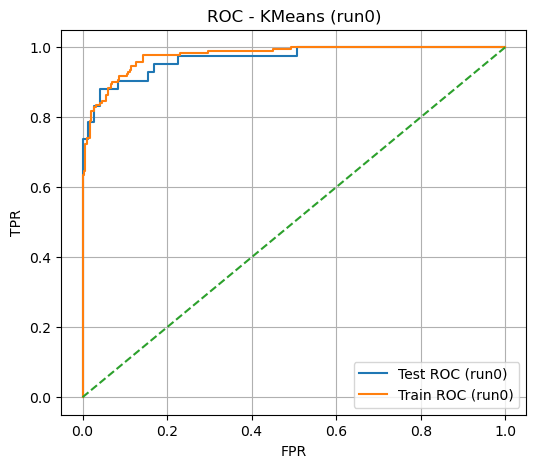

In [124]:
plt.figure(figsize=(6,5))
if roc_fpr_test0 is not None:
    plt.plot(roc_fpr_test0, roc_tpr_test0, label="Test ROC (run0)")
if roc_fpr_run0 is not None:
    plt.plot(roc_fpr_run0, roc_tpr_run0, label="Train ROC (run0)")
plt.plot([0,1],[0,1], "--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC - KMeans (run0)")
plt.legend()
plt.grid()
plt.show()

b(iv)

In [127]:
from sklearn.cluster import SpectralClustering

Spectral clustering (gamma=0.001) TRAIN: ACC 0.9145, P 0.9281, R 0.8353, F1 0.8793, AUC 0.9778
Spectral clustering (gamma=0.001) TEST : ACC 0.9115, P 0.9706, R 0.7857, F1 0.8684, AUC 0.9712
Train confusion matrix:
 [[275  11]
 [ 28 142]]
Test  confusion matrix:
 [[70  1]
 [ 9 33]]


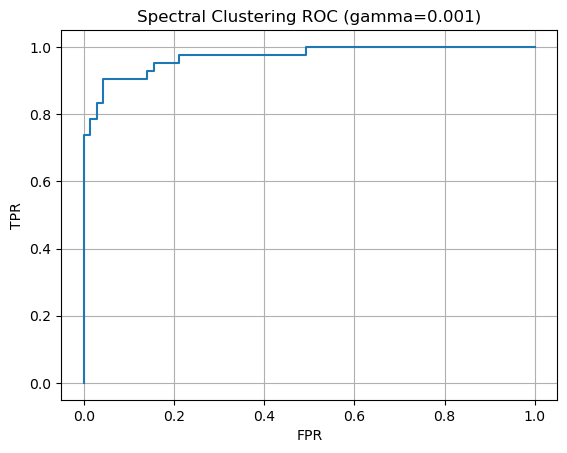

In [132]:
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr = np.asarray(y_test).astype(int)

target_counts = np.bincount(y_train_arr)  

gamma_grid = np.logspace(-3, 1, 25) 

best_gamma = None
best_count_diff = np.inf
best_labels_train = None


for gamma in gamma_grid:
    sc = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma,
                            assign_labels='kmeans', random_state=0)
    labels = sc.fit_predict(X_train_std)  
    counts = np.bincount(labels, minlength=2)

    diff1 = np.sum(np.abs(counts - target_counts))    
    diff2 = np.sum(np.abs(counts[::-1] - target_counts))
    diff = min(diff1, diff2)
    if diff < best_count_diff:
        best_count_diff = diff
        best_gamma = gamma
        best_labels_train = labels.copy()


X_all = np.vstack([X_train_std, X_test_std])
sc_final = SpectralClustering(n_clusters=2, affinity='rbf', gamma=best_gamma,
                              assign_labels='kmeans', random_state=0)
labels_all = sc_final.fit_predict(X_all)

n_train = X_train_std.shape[0]
labels_train_all = labels_all[:n_train]
labels_test_all = labels_all[n_train:]

cluster2class = {}
for c in [0, 1]:
    members = np.where(labels_train_all == c)[0]
    if len(members) == 0:
        cluster2class[c] = 0
    else:
        lab_counts = np.bincount(y_train_arr[members], minlength=2)
        cluster2class[c] = int(np.argmax(lab_counts)) 

pred_train = np.array([cluster2class[c] for c in labels_train_all])
pred_test  = np.array([cluster2class[c] for c in labels_test_all])

centers = []
for c in [0,1]:
    members = np.where(labels_train_all == c)[0]
    if len(members) > 0:
        centers.append(np.mean(X_train_std[members], axis=0))
    else:
        centers.append(np.zeros(X_train_std.shape[1]))
centers = np.vstack(centers) 

pos_centers = [c for c,lbl in cluster2class.items() if lbl == 1]
if len(pos_centers) >= 1:
    pos_idx = pos_centers[0]
    other_idx = 1 - pos_idx
    d_train_cpos = np.linalg.norm(X_train_std - centers[pos_idx], axis=1)
    d_train_cother = np.linalg.norm(X_train_std - centers[other_idx], axis=1)
    score_train = d_train_cother - d_train_cpos
    d_test_cpos = np.linalg.norm(X_test_std - centers[pos_idx], axis=1)
    d_test_cother = np.linalg.norm(X_test_std - centers[other_idx], axis=1)
    score_test = d_test_cother - d_test_cpos
else:
    score_train = -np.linalg.norm(X_train_std - centers[0], axis=1)
    score_test = -np.linalg.norm(X_test_std - centers[0], axis=1)

train_acc = accuracy_score(y_train_arr, pred_train)
train_prec = precision_score(y_train_arr, pred_train, zero_division=0)
train_rec = recall_score(y_train_arr, pred_train, zero_division=0)
train_f1 = f1_score(y_train_arr, pred_train, zero_division=0)
train_auc = roc_auc_score(y_train_arr, score_train)
train_conf = confusion_matrix(y_train_arr, pred_train)

test_acc = accuracy_score(y_test_arr, pred_test)
test_prec = precision_score(y_test_arr, pred_test, zero_division=0)
test_rec = recall_score(y_test_arr, pred_test, zero_division=0)
test_f1 = f1_score(y_test_arr, pred_test, zero_division=0)
test_auc = roc_auc_score(y_test_arr, score_test)
test_conf = confusion_matrix(y_test_arr, pred_test)

print("Spectral clustering (gamma={}) TRAIN: ACC {:.4f}, P {:.4f}, R {:.4f}, F1 {:.4f}, AUC {:.4f}"
      .format(best_gamma, train_acc, train_prec, train_rec, train_f1, train_auc))
print("Spectral clustering (gamma={}) TEST : ACC {:.4f}, P {:.4f}, R {:.4f}, F1 {:.4f}, AUC {:.4f}"
      .format(best_gamma, test_acc, test_prec, test_rec, test_f1, test_auc))


In [134]:
print("Train confusion matrix:\n", train_conf)
print("Test  confusion matrix:\n", test_conf)

Train confusion matrix:
 [[275  11]
 [ 28 142]]
Test  confusion matrix:
 [[70  1]
 [ 9 33]]


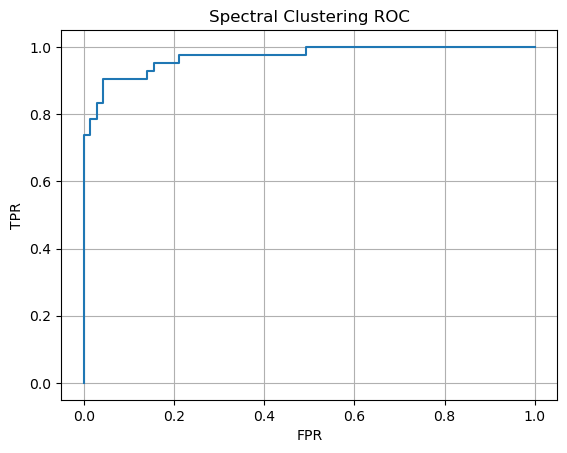

In [135]:
fpr, tpr, _ = roc_curve(y_test_arr, score_test)
plt.plot(fpr, tpr)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"Spectral Clustering ROC")
plt.grid(True)
plt.show()

From the result, supervised learning has the highest accuracy score, semi-supervised learning has the higher score than unsupervised learning. Which is fit the expection.

Part 2

Source:

Random permutation: https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html

How to implement active learning in python: https://spotintelligence.com/2023/08/08/active-learning-in-machine-learning/

How to do matrix calculation: https://alysivji.com/python-matrix-multiplication-operator.html

In [137]:
df2 = pd.read_csv("data_banknote_authentication.txt", header=None)
df2

,0,1,2,3,4
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [148]:
X = df2.iloc[:, : -1]
y = df2.iloc[:, -1]

In [154]:
perm = np.random.permutation(len(X))
test_idx = perm[:472]
train_idx = perm[472:]

X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]


350     0
396     0
1202    1
719     0
589     0
       ..
1346    1
465     0
1006    1
168     0
1084    1
Name: 4, Length: 900, dtype: int64

b(i)

In [165]:
all_errors = []   
scaler = StandardScaler()
X = scaler.fit_transform(X)

for rep in range(50):
    perm = np.random.permutation(len(X))
    test_idx = perm[:472]
    train_idx = perm[472:]

    X_test, y_test = X[test_idx], y[test_idx]
    X_train, y_train = X[train_idx], y[train_idx]
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    pool = np.random.permutation(len(X_train))

    rep_errors = []

    for k in range(1, 91):     
        n_samples = k * 10
        selected = pool[:n_samples]

        X_sub = X_train[selected]
        y_sub = y_train[selected]

        svm = LinearSVC(penalty='l1', dual=False, max_iter=5000)

        param_grid = {'C':[0.1, 1, 10]}
        clf = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1)
        clf.fit(X_sub, y_sub)

        y_pred = clf.predict(X_test)
        error = 1 - accuracy_score(y_test, y_pred)
        rep_errors.append(error)

    all_errors.append(rep_errors)

all_errors = np.array(all_errors)

print(all_errors[0])

Shape: (50, 90)
Example (first repetition):
[0.43855932 0.01059322 0.01271186 0.01059322 0.01271186 0.00635593
 0.00635593 0.00635593 0.00635593 0.00847458 0.00635593 0.00847458
 0.00635593 0.00635593 0.00847458 0.00847458 0.00847458 0.00847458
 0.01694915 0.00635593 0.00635593 0.00635593 0.01059322 0.00847458
 0.00847458 0.00635593 0.00635593 0.00635593 0.00635593 0.00847458
 0.00847458 0.00847458 0.00635593 0.00847458 0.00635593 0.00847458
 0.00847458 0.00847458 0.00635593 0.00847458 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00423729 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00847458 0.00635593 0.00635593 0.00847458
 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458
 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458
 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458 0.00847458
 0.00847458 0.0084

In [171]:
all_errors_active = []
for rep in range(50):

    perm = np.random.permutation(len(X))
    test_idx = perm[:472]
    train_idx = perm[472:]

    X_test, y_test = X[test_idx], y[test_idx]
    X_train =np.array( X[train_idx])
    y_train = np.array(y[train_idx])

    remaining = np.arange(900)
    np.random.shuffle(remaining)

    pool_idx = remaining[:10]           
    remaining = remaining[10:]           
    rep_errors = []

    for k in range(1, 91):

        X_pool = X_train[pool_idx]
        y_pool = y_train[pool_idx]

        svm = LinearSVC(penalty='l1', dual=False, max_iter=5000)
        grid = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1)
        grid.fit(X_pool, y_pool)
        clf = grid.best_estimator_

        y_pred = clf.predict(X_test)
        error = 1 - accuracy_score(y_test, y_pred)
        rep_errors.append(error)

        if len(pool_idx) == 900:
            continue

        w = clf.coef_.flatten()
        b = clf.intercept_[0]

        X_remain = X_train[remaining]
        dist = np.abs(X_remain @ w + b) / np.linalg.norm(w)

        pick = np.argsort(dist)[:10]

        pool_idx = np.concatenate([pool_idx, remaining[pick]])
        remaining = np.delete(remaining, pick)

    all_errors_active.append(rep_errors)


all_errors_active = np.array(all_errors_active)
print( all_errors_active[0])

[0.11864407 0.01483051 0.01271186 0.00847458 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.01059322 0.01059322 0.00635593
 0.00635593 0.01059322 0.00635593 0.01059322 0.01059322 0.01059322
 0.01059322 0.00635593 0.01059322 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593
 0.00635593 0.00635593 0.00635593 0.00635593 0.00635593 0.0063

(c)

In [174]:
train_sizes = np.arange(10, 901, 10)
mean_active = all_errors_active.mean(axis=0)
mean_passive = all_errors.mean(axis=0)

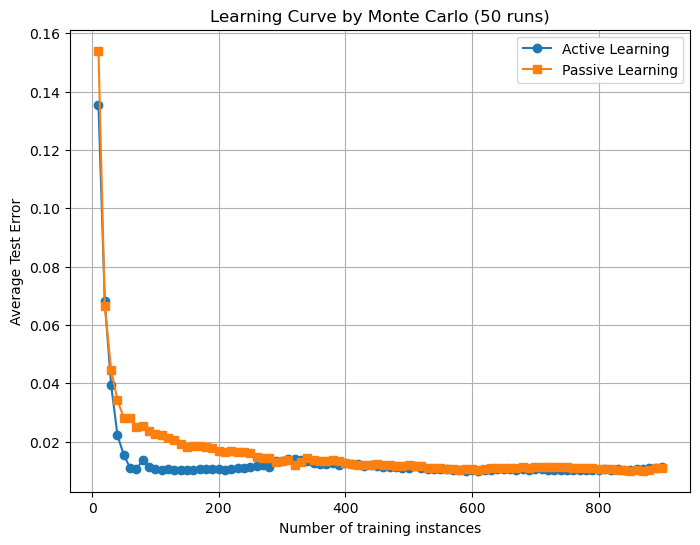

In [175]:
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, mean_active, marker='o', label='Active Learning')
plt.plot(train_sizes, mean_passive, marker='s', label='Passive Learning')
plt.xlabel("Number of training instances")
plt.ylabel("Average Test Error")
plt.title("Learning Curve by Monte Carlo (50 runs)")
plt.legend()
plt.grid(True)
plt.show()